
CLASSIFIER EVALUATION
Accuracy: 0.9766
              precision    recall  f1-score   support

      DONATE       0.98      0.97      0.97      9264
        SELL       0.97      0.98      0.98     10736

    accuracy                           0.98     20000
   macro avg       0.98      0.98      0.98     20000
weighted avg       0.98      0.98      0.98     20000



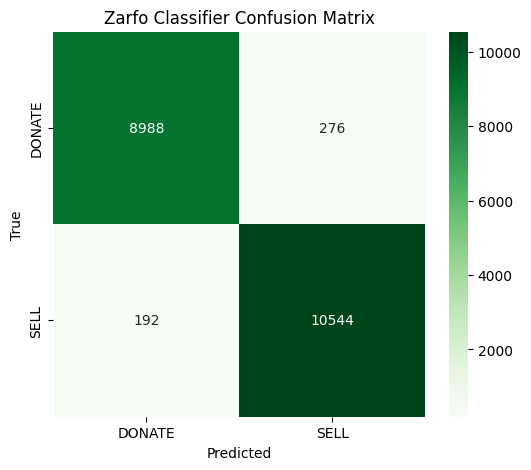

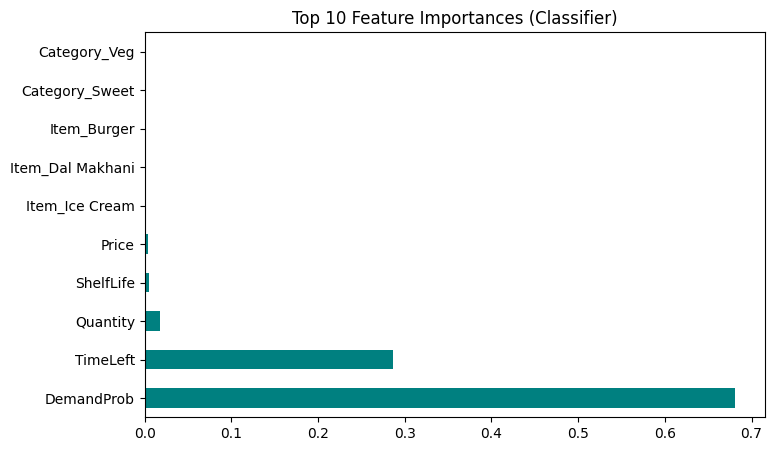


REGRESSOR EVALUATION
Mean Absolute Error (MAE): 6.34
R-squared (R²): 0.9568

Models and LabelEncoder saved successfully as .pkl files.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# 1 Load the dataset
csv_path = "smartserve_synthetic_data.csv"

try:
    df = pd.read_csv(csv_path)
except FileNotFoundError:
    print(f"Error: CSV file not found at {csv_path}. Please ensure the data generation script was run.")
    data = {'Item': ['A'], 'Category': ['Veg'], 'shelf_life': [3], 'quantity': [10], 'time_left': [1.5], 'price': [100], 'demand': [0.5], 'ACTION': ['SELL'], 'SUGGESTED_PRICE': [50]}
    df = pd.DataFrame(data)
except Exception as e:
    print(f"An error occurred loading the CSV: {e}")


# Standardizing the column names
df = df.rename(columns={
    'shelf_life': 'ShelfLife',
    'quantity': 'Quantity',
    'time_left': 'TimeLeft',
    'price': 'Price',
    'demand': 'DemandProb',
    'ACTION': 'Action',
    'SUGGESTED_PRICE': 'SuggestedPrice'
})


# 2. Feature Engineering and Missing data-handling 

# here we are justt clipping the above values to be in real ranges (i.e. ShelfLife cannot be negative or more than 48 hours etc)
df['ShelfLife'] = df['ShelfLife'].clip(lower=1, upper=48)
df['TimeLeft'] = df['TimeLeft'].clip(lower=0, upper=df['ShelfLife'].max())

num_imputer = SimpleImputer(strategy='mean')
cat_imputer = SimpleImputer(strategy='most_frequent')

# here we are filling all the missing values in numerical and categorical columns using a simple imputer
# in simple words, we are replacing missing values with mean (for numerical) and mode (for categorical)
# Impute Numerical Columns
for col in ['ShelfLife', 'Quantity', 'TimeLeft', 'DemandProb', 'Price']:
    df[col] = df[col].astype(float) 
    # FIX: Use [:, 0] to flatten the 2D array output of fit_transform before assignment
    df[col] = num_imputer.fit_transform(df[[col]])[:, 0]
# Impute Categorical Columns
for col in ['Item', 'Category']:
    df[col] = df[col].astype(str)
    # FIX: Use [:, 0] to flatten the 2D array output of fit_transform before assignment
    df[col] = cat_imputer.fit_transform(df[[col]])[:, 0]

# just drop the rows from the dataset where we dont have any target variable set i.e. Action or SuggestedPrice
df.dropna(subset=['Action', 'SuggestedPrice'], inplace=True)

# encoding target variable 'Action' (SELL/DONATE)
le = LabelEncoder()
df['Action_Encoded'] = le.fit_transform(df['Action'])

# 3. Split data for Classifier & Regressor

# Classifier predicts 'SELL' v/s 'DONATE'
X_clf = df.drop(columns=['Action', 'Action_Encoded', 'SuggestedPrice'])
y_clf = df['Action_Encoded']

# Regressor predicts Suggested Price (but only for SELL items)
df_reg = df[df['Action'] == 'SELL'].copy()
X_reg = df_reg.drop(columns=['Action', 'Action_Encoded', 'SuggestedPrice'])
y_reg = df_reg['SuggestedPrice']

# 4. Preprocessing Pipelines (Scaling + Encoding)
numerical_features = ['ShelfLife', 'Quantity', 'TimeLeft', 'DemandProb', 'Price']
categorical_features = ['Item', 'Category']
# Combined Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='drop'
)


# 5. Training the Classifier Model
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)
# Classifier Pipeline
clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=150,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ))
])

clf_pipeline.fit(X_train_clf, y_train_clf)
y_pred_clf = clf_pipeline.predict(X_test_clf)

print("\nCLASSIFIER EVALUATION")
# Classification Metrics (where we are calculating accuracy and other metrics indicating how well our classifier is performing)
print(f"Accuracy: {accuracy_score(y_test_clf, y_pred_clf):.4f}")
print(classification_report(y_test_clf, y_pred_clf, target_names=le.classes_))
# Confusion Matrix (i.e here we are calculating how many times our classifier predicted SELL when it was actually DONATE and vice versa)
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test_clf, y_pred_clf), annot=True, fmt='d',
             cmap='Greens', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Zarfo Classifier Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Feature Importance Plot for Classifier (to see which features are most important for the classifier)
feature_names = numerical_features + list(
    clf_pipeline['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)
)
importances = clf_pipeline['classifier'].feature_importances_
pd.Series(importances, index=feature_names).nlargest(10).plot(kind='barh', figsize=(8, 5), color='teal')
plt.title("Top 10 Feature Importances (Classifier)")
plt.show()

# 6. Training Regressor Model
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)
# Regressor Pipeline 
reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=120,
        random_state=42,
        n_jobs=-1
    ))
])
# Training Regressor Model
reg_pipeline.fit(X_train_reg, y_train_reg)
y_pred_reg = reg_pipeline.predict(X_test_reg)

print("\nREGRESSOR EVALUATION")
# Regression Metrics (to see how well our regressor is performing)
# MAE shows average error in price prediction andd R² indicates variance explained by the model
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test_reg, y_pred_reg):.2f}")
print(f"R-squared (R²): {r2_score(y_test_reg, y_pred_reg):.4f}")

# 7. Save Trained Models
joblib.dump(clf_pipeline, 'zarfo_classifier_pipeline.pkl')
joblib.dump(reg_pipeline, 'zarfo_regressor_pipeline.pkl')
joblib.dump(le, 'zarfo_label_encoder.pkl')

# simple message indicating the models have been trained and saved successfully as .pkl files
print("\nModels and LabelEncoder saved successfully as .pkl files.")

In [2]:
print(df['Action'].value_counts())

Action
SELL      53678
DONATE    46322
Name: count, dtype: int64
